In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/medical_cost_prediction.csv')

In [4]:
df.head()

,age,gender,bmi,smoker,region,annual_charges
0,58,male,34.75,no,northeast,15076.80
1,52,male,30.75,no,northeast,11109.19
2,31,male,28.61,yes,southwest,25644.67
3,18,male,29.95,no,southeast,5905.49
4,31,female,34.70,no,southeast,9728.90


In [5]:
df.tail()

,age,gender,bmi,smoker,region,annual_charges
495,40,male,21.29,no,northwest,11346.79
496,49,female,30.75,yes,northwest,27151.24
497,39,male,31.49,no,southeast,10996.55
498,38,male,37.90,no,northeast,13133.92
499,41,male,31.09,no,southwest,10224.87


In [6]:
df.shape

(500, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             500 non-null    int64  
 1   gender          500 non-null    object 
 2   bmi             500 non-null    float64
 3   smoker          500 non-null    object 
 4   region          500 non-null    object 
 5   annual_charges  500 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 23.6+ KB


In [8]:
df.isnull().sum()

,0
age,0
gender,0
bmi,0
smoker,0
region,0
annual_charges,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,age,bmi,annual_charges
count,500.000000,500.000000,500.000000
mean,41.698000,29.912400,14729.739840
std,13.251642,5.973788,8308.729998
min,18.000000,15.000000,5064.240000
25%,31.000000,25.607500,9658.602500
50%,42.000000,30.230000,11593.500000
75%,53.000000,33.887500,14351.145000
max,64.000000,45.750000,39799.430000


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

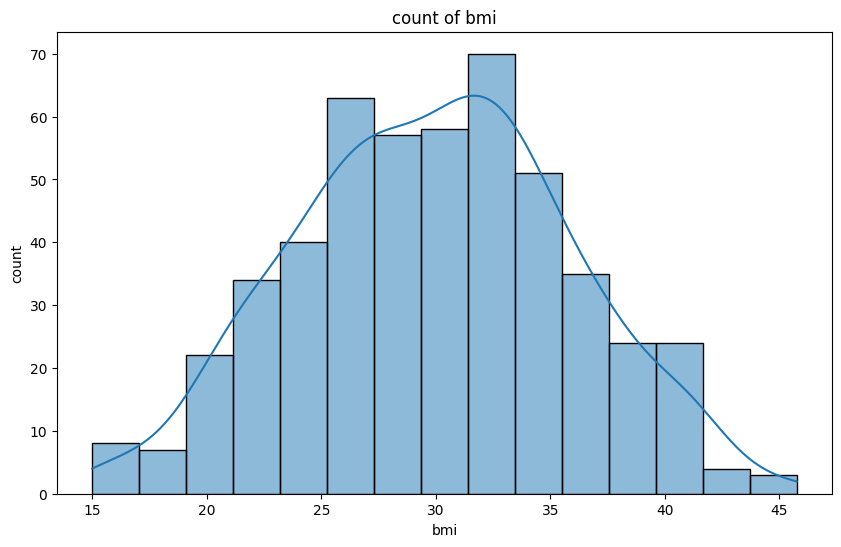

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(x='bmi',data=df,kde=True)
plt.title('count of bmi')
plt.xlabel('bmi')
plt.ylabel('count')
plt.show()

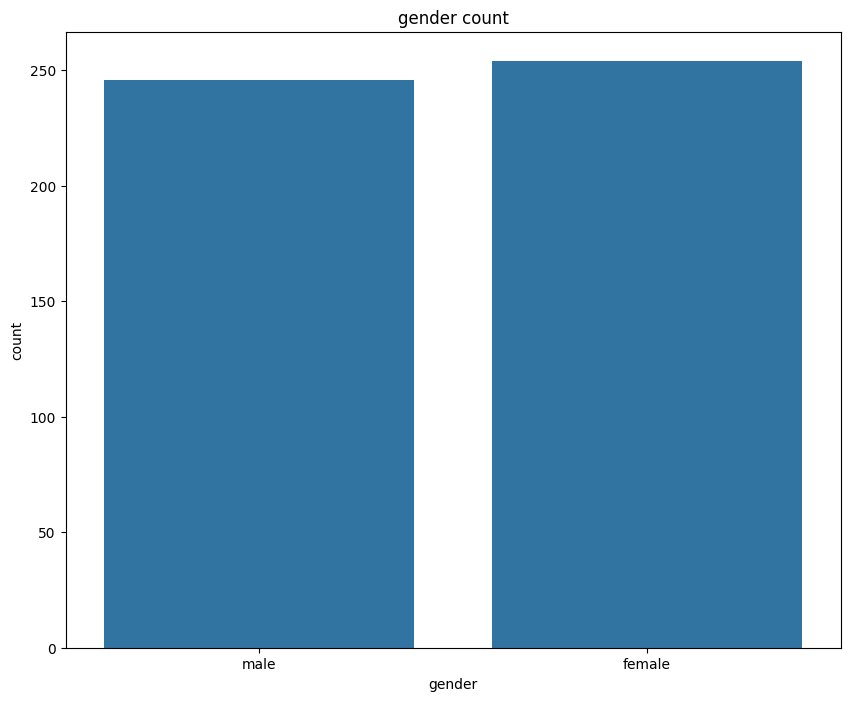

In [33]:
plt.figure(figsize=(10,8))
sns.countplot(x='gender',data=df)
plt.title('gender count')
plt.show()

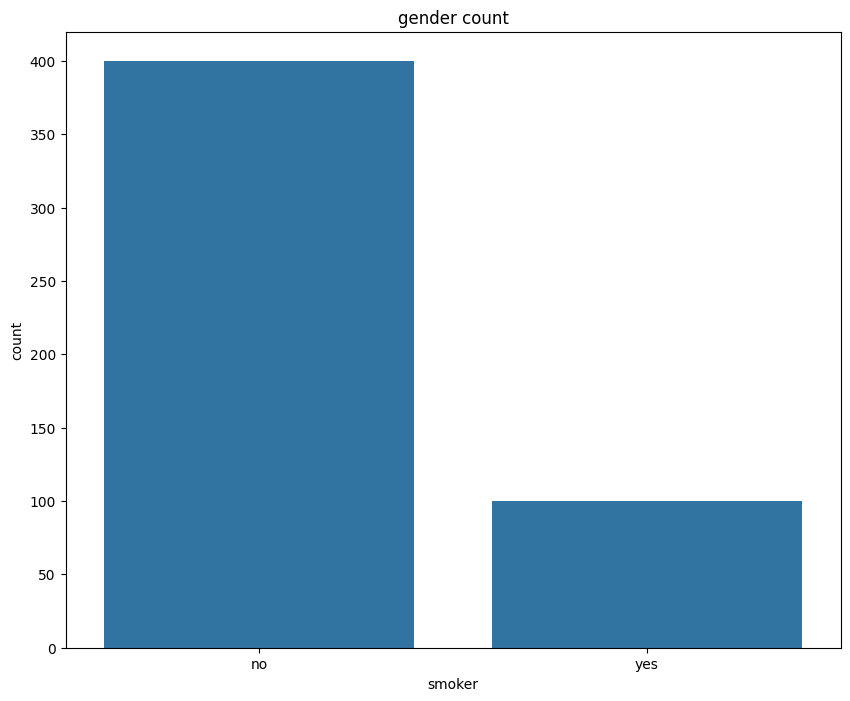

In [34]:
plt.figure(figsize=(10,8))
sns.countplot(x='smoker',data=df)
plt.title('gender count')
plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
encoder = LabelEncoder()

In [37]:
df.select_dtypes(include='object').columns

Index(['gender', 'smoker', 'region'], dtype='object')

In [38]:
obj_col = ['gender', 'smoker', 'region']

In [39]:
for col in obj_col:
  df[col] = encoder.fit_transform(df[col])

In [40]:
df.head()

,age,gender,bmi,smoker,region,annual_charges
0,58,1,34.75,0,0,15076.80
1,52,1,30.75,0,0,11109.19
2,31,1,28.61,1,3,25644.67
3,18,1,29.95,0,2,5905.49
4,31,0,34.70,0,2,9728.90


In [41]:
df.tail()

,age,gender,bmi,smoker,region,annual_charges
495,40,1,21.29,0,1,11346.79
496,49,0,30.75,1,1,27151.24
497,39,1,31.49,0,2,10996.55
498,38,1,37.90,0,0,13133.92
499,41,1,31.09,0,3,10224.87


In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X = df.iloc[:,:-1]

In [44]:
y = df['annual_charges']

In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
model = LinearRegression()

In [48]:
model.fit(X_train,y_train)

LinearRegression()

In [49]:
y_pred = model.predict(X_test)

In [50]:
from sklearn.metrics import r2_score,mean_squared_error

In [51]:
print("=== Linear Regression ===")
r2 = r2_score(y_test,y_pred)
print(f'your r2_score is: {r2}')
mse = mean_squared_error(y_test,y_pred)
print(f'your mean-squared_error is: {mse}')

=== Linear Regression ===
your r2_score is: 0.9484889845070545
your mean-squared_error is: 3570628.482448104


In [52]:
new_user_data = {
    'age': [30],      # Example age
    'gender': [0],    # Example gender: 0 for female, 1 for male (based on previous encoding)
    'bmi': [25.0],    # Example BMI
    'smoker': [0],    # Example smoker status: 0 for no, 1 for yes (based on previous encoding)
    'region': [0]     # Example region: 0 for northeast (based on previous encoding)
}

new_user_df = pd.DataFrame(new_user_data)

predicted_charge = model.predict(new_user_df)
print(f"Predicted annual charges for the new user: ${predicted_charge[0]:.2f}")

Predicted annual charges for the new user: $9412.53
